## return premium ablation

value-weighted return premium for missing vs observed chars, within firm-quality segments (size, FF10 industry, OP, LEV, B2M, sub-period).

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imputation_utils import char_groupings, char_maps

data = np.load('../data/raw_rank_trunk_chars.npz')
percentile_rank_chars = data['rank_chars']
regular_chars = data['raw_chars']
chars = data['chars']
dates = data['dates']
return_panel = data['returns']
permnos = data['permnos']
rts = data['rfs']
monthly_updates = data['monthly_updates']

T, N, C = percentile_rank_chars.shape

In [22]:
PORT_TGT_CHARS = [
    'A2ME', 'AT', 'ATO', 'B2M', 'C2A', 'CF2B', 'CF2P', 'CTO', 'D2A', 'DPI2A',
    'E2P', 'FC2Y', 'INV', 'LEV', 'NI', 'NOA', 'OA', 'OL', 'OP', 'PCM',
    'PM', 'PROF', 'Q', 'RNA', 'ROA', 'ROE', 'S2P', 'SGA2S',
]
RETURN_LAG = 6
WARMUP = 45

def vw_ret(mask, sizes, ret_vec):
    w = mask.astype(float) * np.nan_to_num(sizes)
    s = np.sum(w)
    if s < 1e-10:
        return np.nan
    return (w / s) @ np.nan_to_num(ret_vec)


# Assisted by Claude
def compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                           chars, segment_mask, return_lag=RETURN_LAG, start=WARMUP):
    size_ind = np.argwhere(chars == 'ME')[0][0]

    if segment_mask.ndim == 1:
        segment_mask = np.broadcast_to(segment_mask[np.newaxis, :],
                                        (percentile_rank_chars.shape[0], len(segment_mask)))

    prev_obs_mask = np.any(~np.isnan(percentile_rank_chars[:start]), axis=0)

    obs_ts = {c: [] for c in PORT_TGT_CHARS}
    mis_ts = {c: [] for c in PORT_TGT_CHARS}

    for t in range(start, T - return_lag):
        sizes = regular_chars[t, :, size_ind]
        ret_fwd = return_panel[t + return_lag]
        has_size = ~np.isnan(sizes)
        has_return = ~np.isnan(ret_fwd)
        seg = segment_mask[t]

        for char_name in PORT_TGT_CHARS:
            i = np.argwhere(chars == char_name)[0][0]
            present = ~np.isnan(percentile_rank_chars[t, :, i])
            base = has_size & has_return & seg

            p_obs = present & base
            p_mis = (~present) & prev_obs_mask[:, i] & base

            obs_ts[char_name].append(vw_ret(p_obs, sizes, ret_fwd))
            mis_ts[char_name].append(vw_ret(p_mis, sizes, ret_fwd))

        prev_obs_mask = prev_obs_mask | (~np.isnan(percentile_rank_chars[t]))

    rows = []
    for char_name in PORT_TGT_CHARS:
        o = np.array(obs_ts[char_name])
        m = np.array(mis_ts[char_name])
        diff = m - o
        valid = ~np.isnan(diff)
        n = np.sum(valid)
        prem = np.nanmean(diff)
        tstat = (prem / (np.nanstd(diff) / np.sqrt(n))) if n > 1 else np.nan
        rows.append(dict(
            char=char_name,
            obs_mean=1200 * np.nanmean(o),
            mis_mean=1200 * np.nanmean(m),
            premium=1200 * prem,
            t_stat=tstat,
            n_obs=int(np.sum(~np.isnan(o))),
            n_mis=int(np.sum(~np.isnan(m))),
        ))

    return pd.DataFrame(rows).set_index('char')

### baseline

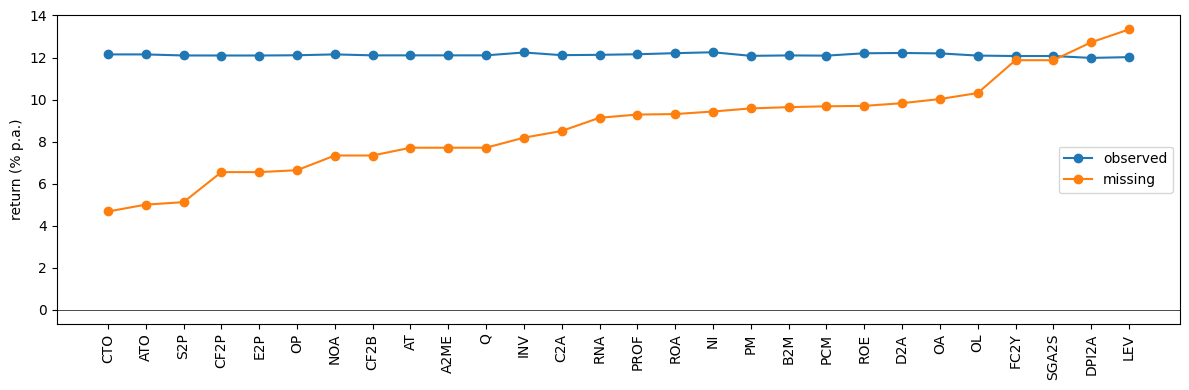

CPU times: user 5.39 s, sys: 1.24 s, total: 6.63 s
Wall time: 7.07 s


,obs_mean,mis_mean,premium,t_stat
char,,,,
A2ME,12.10,7.71,-4.39,-1.47
AT,12.10,7.71,-4.40,-1.47
ATO,12.15,5.00,-7.15,-2.92
B2M,12.10,9.64,-2.46,-0.78
C2A,12.11,8.51,-3.61,-1.65
CF2B,12.10,7.34,-4.76,-1.82
CF2P,12.10,6.55,-5.55,-1.95
CTO,12.15,4.68,-7.47,-3.02
D2A,12.22,9.83,-2.39,-1.83


In [23]:
%%time

all_firms_mask = np.ones((T, N), dtype=bool)
baseline = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, all_firms_mask)

ordering = np.argsort(baseline['mis_mean'].values)
ordered_chars = baseline.index[ordering]
obs_vals = baseline['obs_mean'].values[ordering]
mis_vals = baseline['mis_mean'].values[ordering]

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(PORT_TGT_CHARS))
ax.plot(x, obs_vals, label='observed', marker='o')
ax.plot(x, mis_vals, label='missing', marker='o')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(ordered_chars, rotation=90)
ax.set_ylabel('return (% p.a.)')
ax.legend()
plt.savefig('../images-pdfs/ablation_baseline_returns.pdf', bbox_inches='tight')
plt.show()

baseline[['obs_mean','mis_mean','premium','t_stat']].round(2)

### size quintiles

In [24]:
size_ind = np.argwhere(chars == 'ME')[0][0]

# Assisted by Claude
def build_quintile_masks(char_panel, char_idx, n=5):
    T_, N_ = char_panel.shape[0], char_panel.shape[1]
    masks = [np.zeros((T_, N_), dtype=bool) for _ in range(n)]
    for t in range(T_):
        vals = char_panel[t, :, char_idx]
        valid = ~np.isnan(vals)
        if np.sum(valid) < n:
            continue
        qs = np.nanquantile(vals[valid], np.linspace(0, 1, n + 1))
        for q in range(n):
            lo, hi = qs[q], qs[q + 1]
            in_bin = valid & (vals >= lo if q == 0 else vals > lo) & (vals <= hi)
            masks[q][t] = in_bin
    return masks

size_masks = build_quintile_masks(regular_chars, size_ind)

In [25]:
%%time

size_results = []
for q, mask in enumerate(size_masks):
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    size_results.append(res)

CPU times: user 23.1 s, sys: 1.36 s, total: 24.4 s
Wall time: 25.6 s


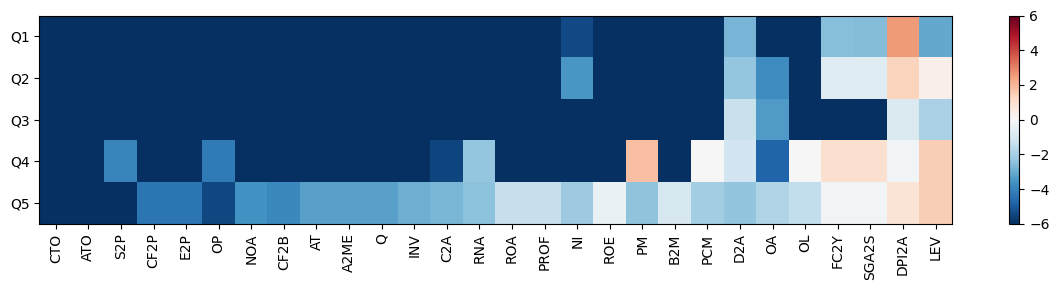

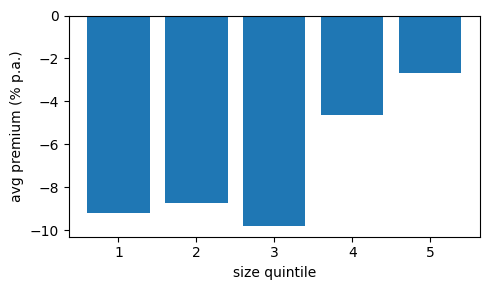

In [26]:
prem_matrix_size = np.array([r['premium'].values for r in size_results])
ordered_chars_idx = np.argsort(baseline['premium'].values)
ordered_chars_names = [PORT_TGT_CHARS[i] for i in ordered_chars_idx]

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(prem_matrix_size[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
               vmin=-6, vmax=6)
ax.set_yticks(range(5))
ax.set_yticklabels([f'Q{i+1}' for i in range(5)])
ax.set_xticks(range(len(PORT_TGT_CHARS)))
ax.set_xticklabels(ordered_chars_names, rotation=90)
plt.colorbar(im, ax=ax)
plt.savefig('../images-pdfs/ablation_size_heatmap.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(1, 6), [r['premium'].mean() for r in size_results])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('size quintile')
ax.set_ylabel('avg premium (% p.a.)')
plt.savefig('../images-pdfs/ablation_size_avg_premium.pdf', bbox_inches='tight')
plt.show()

### FF10 industries

In [27]:
sic_fic = pd.read_csv('../data/sic_fic.csv')

sic_latest = (
    sic_fic.sort_values('datadate')
    .dropna(subset=['sic'])
    .groupby('LPERMNO')['sic']
    .last()
    .reset_index()
)
sic_latest.columns = ['permno', 'sic']
sic_latest['sic'] = sic_latest['sic'].astype(int)


# Assisted by Claude
def sic_to_ff10(sic):
    if pd.isna(sic):
        return 'Other'
    s = int(sic)
    if (100 <= s <= 999) or (2000 <= s <= 2399) or (2700 <= s <= 2749) or \
       (2770 <= s <= 2799) or (3100 <= s <= 3199) or (3940 <= s <= 3989):
        return 'NoDur'
    if (2500 <= s <= 2519) or (2590 <= s <= 2599) or (3630 <= s <= 3659) or \
       s in [3710, 3711, 3714, 3716] or (3750 <= s <= 3751) or \
       s == 3792 or (3900 <= s <= 3939) or (3990 <= s <= 3999):
        return 'Durbl'
    if (2520 <= s <= 2589) or (2600 <= s <= 2699) or (2750 <= s <= 2769) or \
       (2800 <= s <= 2829) or (2840 <= s <= 2899) or (3000 <= s <= 3099) or \
       (3200 <= s <= 3569) or (3580 <= s <= 3629) or (3700 <= s <= 3709) or \
       s in [3712, 3713, 3715] or (3717 <= s <= 3749) or \
       (3752 <= s <= 3791) or (3793 <= s <= 3799) or (3830 <= s <= 3839) or \
       (3860 <= s <= 3899):
        return 'Manuf'
    if (1200 <= s <= 1399) or (2900 <= s <= 2999):
        return 'Enrgy'
    if (2830 <= s <= 2836) or (8000 <= s <= 8099):
        return 'Hlth'
    if (3570 <= s <= 3579) or (3660 <= s <= 3699) or \
       (3810 <= s <= 3829) or (7370 <= s <= 7379):
        return 'BusEq'
    if (4800 <= s <= 4899):
        return 'Telcm'
    if (4900 <= s <= 4949):
        return 'Utils'
    if (5000 <= s <= 5999) or (7200 <= s <= 7299) or (7600 <= s <= 7699):
        return 'Shops'
    return 'Other'


sic_latest['industry'] = sic_latest['sic'].apply(sic_to_ff10)

permno_to_ind = dict(zip(sic_latest['permno'].astype(int), sic_latest['industry']))
firm_industries = np.array([permno_to_ind.get(int(p), 'Other') for p in permnos])

FF10_ORDER = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'Hlth', 'BusEq', 'Telcm', 'Utils', 'Shops', 'Other']
industries_present = [ind for ind in FF10_ORDER if np.any(firm_industries == ind)]

industry_masks = {ind: (firm_industries == ind) for ind in industries_present}

In [28]:
%%time

industry_results = {}
for ind in industries_present:
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, industry_masks[ind])
    industry_results[ind] = res

CPU times: user 42.7 s, sys: 2.44 s, total: 45.2 s
Wall time: 45.8 s


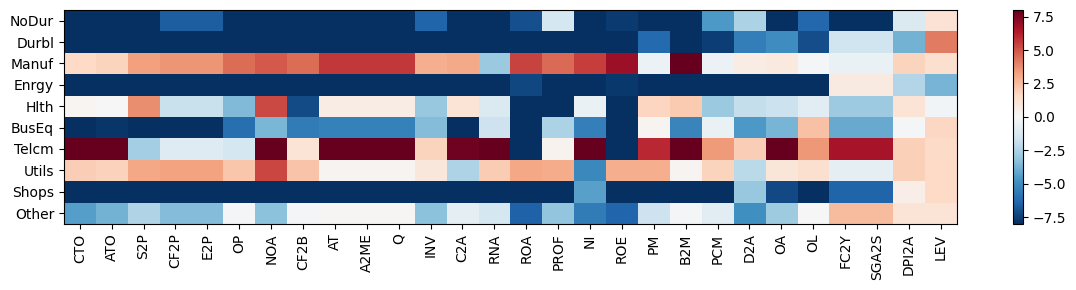

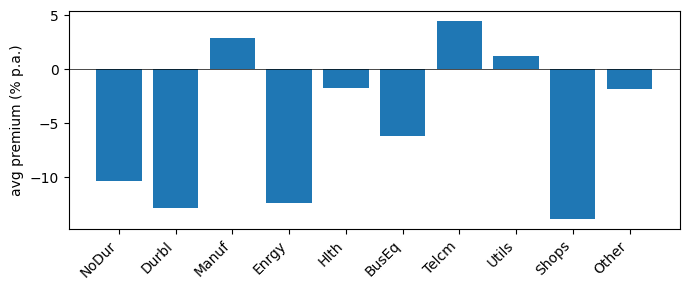

In [29]:
prem_matrix_ind = np.array([industry_results[ind]['premium'].values
                             for ind in industries_present])

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(prem_matrix_ind[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
               vmin=-8, vmax=8)
ax.set_yticks(range(len(industries_present)))
ax.set_yticklabels(industries_present)
ax.set_xticks(range(len(PORT_TGT_CHARS)))
ax.set_xticklabels(ordered_chars_names, rotation=90)
plt.colorbar(im, ax=ax)
plt.savefig('../images-pdfs/ablation_industry_heatmap.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(industries_present)),
       [industry_results[ind]['premium'].mean() for ind in industries_present])
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(range(len(industries_present)))
ax.set_xticklabels(industries_present, rotation=45, ha='right')
ax.set_ylabel('avg premium (% p.a.)')
plt.savefig('../images-pdfs/ablation_industry_avg_premium.pdf', bbox_inches='tight')
plt.show()

### OP quintiles

In [30]:
%%time

op_ind = np.argwhere(chars == 'OP')[0][0]
op_masks = build_quintile_masks(percentile_rank_chars, op_ind)

op_results = []
for q, mask in enumerate(op_masks):
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    op_results.append(res)

CPU times: user 20.3 s, sys: 1.07 s, total: 21.4 s
Wall time: 21.5 s


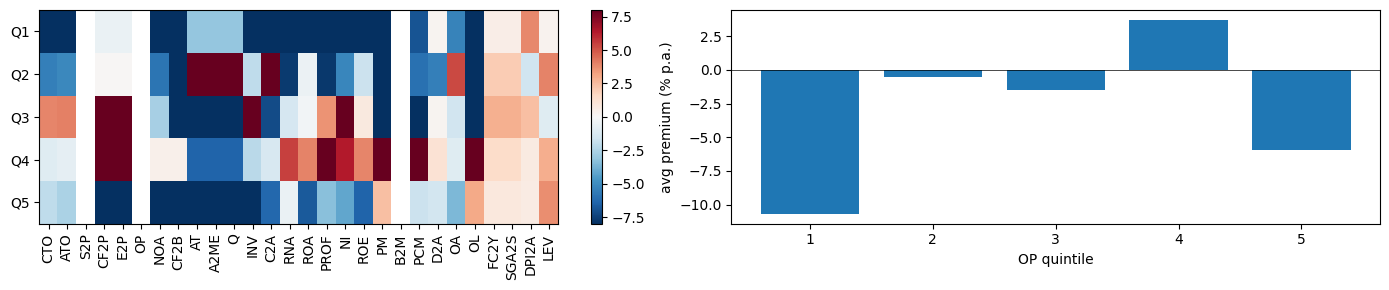

In [31]:
prem_matrix_op = np.array([r['premium'].values for r in op_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

im = axes[0].imshow(prem_matrix_op[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(5)])
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90)
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(1, 6), [r['premium'].mean() for r in op_results])
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('OP quintile')
axes[1].set_ylabel('avg premium (% p.a.)')

plt.savefig('../images-pdfs/ablation_op_quintiles.pdf', bbox_inches='tight')
plt.show()

### LEV quintiles

In [32]:
%%time

lev_ind = np.argwhere(chars == 'LEV')[0][0]
lev_masks = build_quintile_masks(percentile_rank_chars, lev_ind)

lev_results = []
for q, mask in enumerate(lev_masks):
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    lev_results.append(res)

CPU times: user 21.3 s, sys: 1.04 s, total: 22.3 s
Wall time: 23.1 s


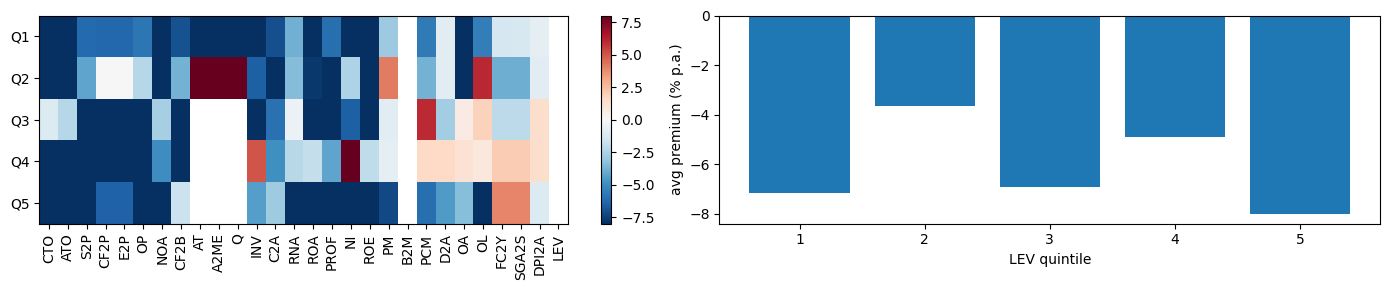

In [33]:
prem_matrix_lev = np.array([r['premium'].values for r in lev_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

im = axes[0].imshow(prem_matrix_lev[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(5)])
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90)
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(1, 6), [r['premium'].mean() for r in lev_results])
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('LEV quintile')
axes[1].set_ylabel('avg premium (% p.a.)')

plt.savefig('../images-pdfs/ablation_lev_quintiles.pdf', bbox_inches='tight')
plt.show()

### B2M quintiles

In [34]:
%%time

b2m_ind = np.argwhere(chars == 'B2M')[0][0]
b2m_masks = build_quintile_masks(percentile_rank_chars, b2m_ind)

b2m_results = []
for q, mask in enumerate(b2m_masks):
    res = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                  chars, mask)
    res['quintile'] = q + 1
    b2m_results.append(res)

CPU times: user 21.4 s, sys: 836 ms, total: 22.3 s
Wall time: 22.7 s


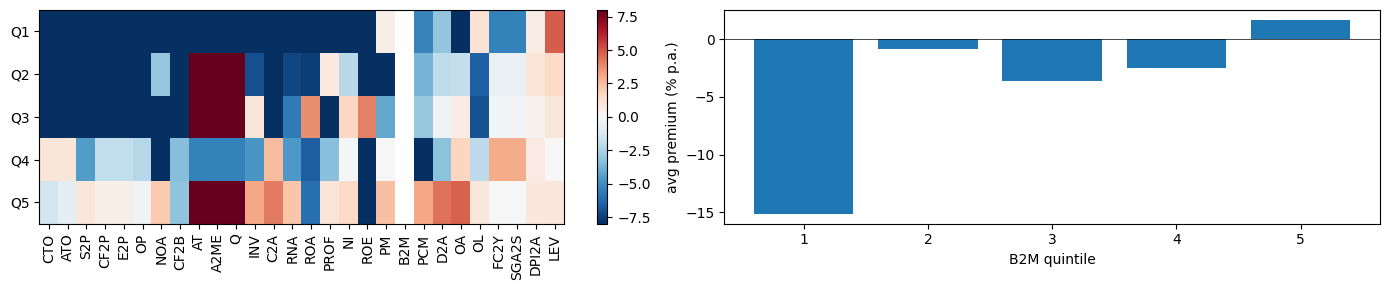

In [35]:
prem_matrix_b2m = np.array([r['premium'].values for r in b2m_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

im = axes[0].imshow(prem_matrix_b2m[:, ordered_chars_idx], aspect='auto', cmap='RdBu_r',
                    vmin=-8, vmax=8)
axes[0].set_yticks(range(5))
axes[0].set_yticklabels([f'Q{i+1}' for i in range(5)])
axes[0].set_xticks(range(len(PORT_TGT_CHARS)))
axes[0].set_xticklabels(ordered_chars_names, rotation=90)
plt.colorbar(im, ax=axes[0])

axes[1].bar(range(1, 6), [r['premium'].mean() for r in b2m_results])
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('B2M quintile')
axes[1].set_ylabel('avg premium (% p.a.)')

plt.savefig('../images-pdfs/ablation_b2m_quintiles.pdf', bbox_inches='tight')
plt.show()

### sub-periods

In [36]:
%%time

split_date = 19990101
post_mask = np.zeros((T, N), dtype=bool)
pre_mask = np.zeros((T, N), dtype=bool)

for t, d in enumerate(dates):
    if d >= split_date:
        post_mask[t, :] = True
    else:
        pre_mask[t, :] = True

pre_result = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                    chars, pre_mask)
post_result = compute_return_premium(percentile_rank_chars, regular_chars, return_panel,
                                     chars, post_mask)

CPU times: user 7.37 s, sys: 842 ms, total: 8.21 s
Wall time: 8.46 s


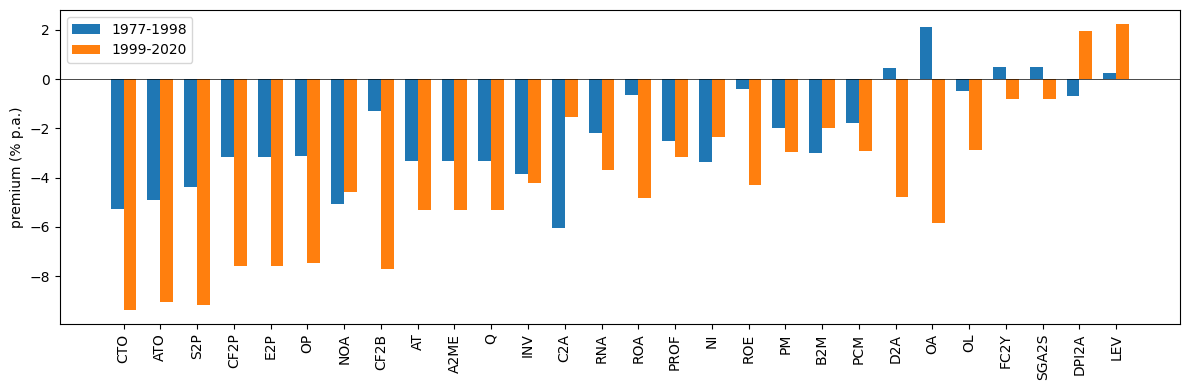

In [37]:
x = np.arange(len(PORT_TGT_CHARS))
width = 0.35

pre_prems = pre_result['premium'].values[ordered_chars_idx]
post_prems = post_result['premium'].values[ordered_chars_idx]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, pre_prems, width, label='1977-1998')
ax.bar(x + width/2, post_prems, width, label='1999-2020')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(ordered_chars_names, rotation=90)
ax.set_ylabel('premium (% p.a.)')
ax.legend()
plt.savefig('../images-pdfs/ablation_subperiod_premium.pdf', bbox_inches='tight')
plt.show()

### summary

In [38]:
summary_rows = []

summary_rows.append({'Segment': 'Full sample', 'Avg premium (% p.a.)': baseline['premium'].mean(),
                     'Avg |t-stat|': baseline['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'Size Q{q+1}',
                         'Avg premium (% p.a.)': size_results[q]['premium'].mean(),
                         'Avg |t-stat|': size_results[q]['t_stat'].abs().mean()})

for ind in industries_present:
    summary_rows.append({'Segment': f'Industry: {ind}',
                         'Avg premium (% p.a.)': industry_results[ind]['premium'].mean(),
                         'Avg |t-stat|': industry_results[ind]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'OP Q{q+1}',
                         'Avg premium (% p.a.)': op_results[q]['premium'].mean(),
                         'Avg |t-stat|': op_results[q]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'LEV Q{q+1}',
                         'Avg premium (% p.a.)': lev_results[q]['premium'].mean(),
                         'Avg |t-stat|': lev_results[q]['t_stat'].abs().mean()})

for q in range(5):
    summary_rows.append({'Segment': f'B2M Q{q+1}',
                         'Avg premium (% p.a.)': b2m_results[q]['premium'].mean(),
                         'Avg |t-stat|': b2m_results[q]['t_stat'].abs().mean()})

summary_rows.append({'Segment': 'Pre-1999',
                     'Avg premium (% p.a.)': pre_result['premium'].mean(),
                     'Avg |t-stat|': pre_result['t_stat'].abs().mean()})
summary_rows.append({'Segment': 'Post-1999',
                     'Avg premium (% p.a.)': post_result['premium'].mean(),
                     'Avg |t-stat|': post_result['t_stat'].abs().mean()})

summary_df = pd.DataFrame(summary_rows).set_index('Segment').round(2)
summary_df

,Avg premium (% p.a.),Avg |t-stat|
Segment,,
Full sample,-3.38,1.46
Size Q1,-9.21,2.09
Size Q2,-8.71,2.17
Size Q3,-9.81,2.62
Size Q4,-4.63,1.47
Size Q5,-2.68,1.03
Industry: NoDur,-10.36,1.44
Industry: Durbl,-12.85,1.31
Industry: Manuf,2.87,0.68


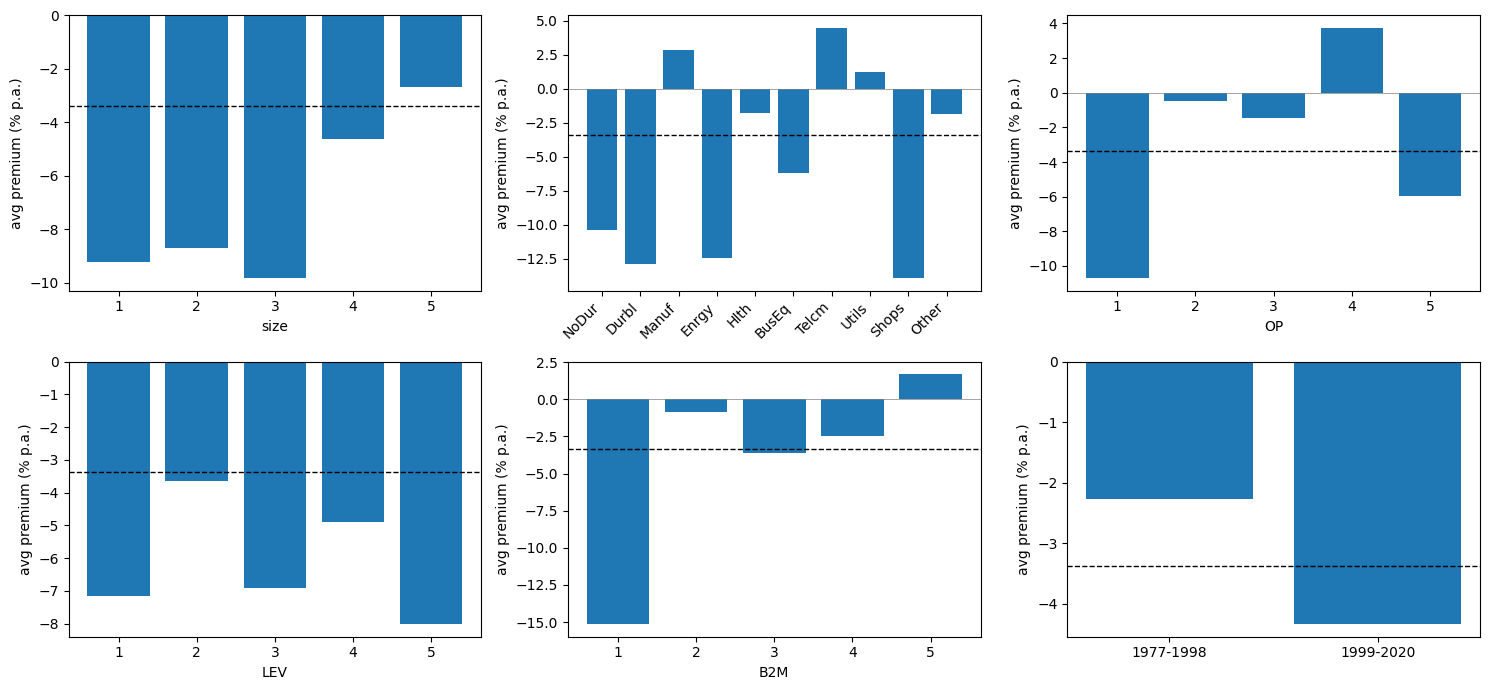

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

axes[0, 0].bar(range(1, 6), [r['premium'].mean() for r in size_results])
axes[0, 0].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[0, 0].axhline(0, color='gray', linewidth=0.5)
axes[0, 0].set_xlabel('size')
axes[0, 0].set_ylabel('avg premium (% p.a.)')

axes[0, 1].bar(range(len(industries_present)),
               [industry_results[ind]['premium'].mean() for ind in industries_present])
axes[0, 1].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[0, 1].axhline(0, color='gray', linewidth=0.5)
axes[0, 1].set_xticks(range(len(industries_present)))
axes[0, 1].set_xticklabels(industries_present, rotation=45, ha='right')
axes[0, 1].set_ylabel('avg premium (% p.a.)')

axes[0, 2].bar(range(1, 6), [r['premium'].mean() for r in op_results])
axes[0, 2].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[0, 2].axhline(0, color='gray', linewidth=0.5)
axes[0, 2].set_xlabel('OP')
axes[0, 2].set_ylabel('avg premium (% p.a.)')

axes[1, 0].bar(range(1, 6), [r['premium'].mean() for r in lev_results])
axes[1, 0].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[1, 0].axhline(0, color='gray', linewidth=0.5)
axes[1, 0].set_xlabel('LEV')
axes[1, 0].set_ylabel('avg premium (% p.a.)')

axes[1, 1].bar(range(1, 6), [r['premium'].mean() for r in b2m_results])
axes[1, 1].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[1, 1].axhline(0, color='gray', linewidth=0.5)
axes[1, 1].set_xlabel('B2M')
axes[1, 1].set_ylabel('avg premium (% p.a.)')

axes[1, 2].bar([0, 1], [pre_result['premium'].mean(), post_result['premium'].mean()])
axes[1, 2].axhline(baseline['premium'].mean(), color='k', linestyle='--', linewidth=1)
axes[1, 2].axhline(0, color='gray', linewidth=0.5)
axes[1, 2].set_xticks([0, 1])
axes[1, 2].set_xticklabels(['1977-1998', '1999-2020'])
axes[1, 2].set_ylabel('avg premium (% p.a.)')

plt.tight_layout()
plt.savefig('../images-pdfs/ablation_summary_6panel.pdf', bbox_inches='tight')
plt.show()

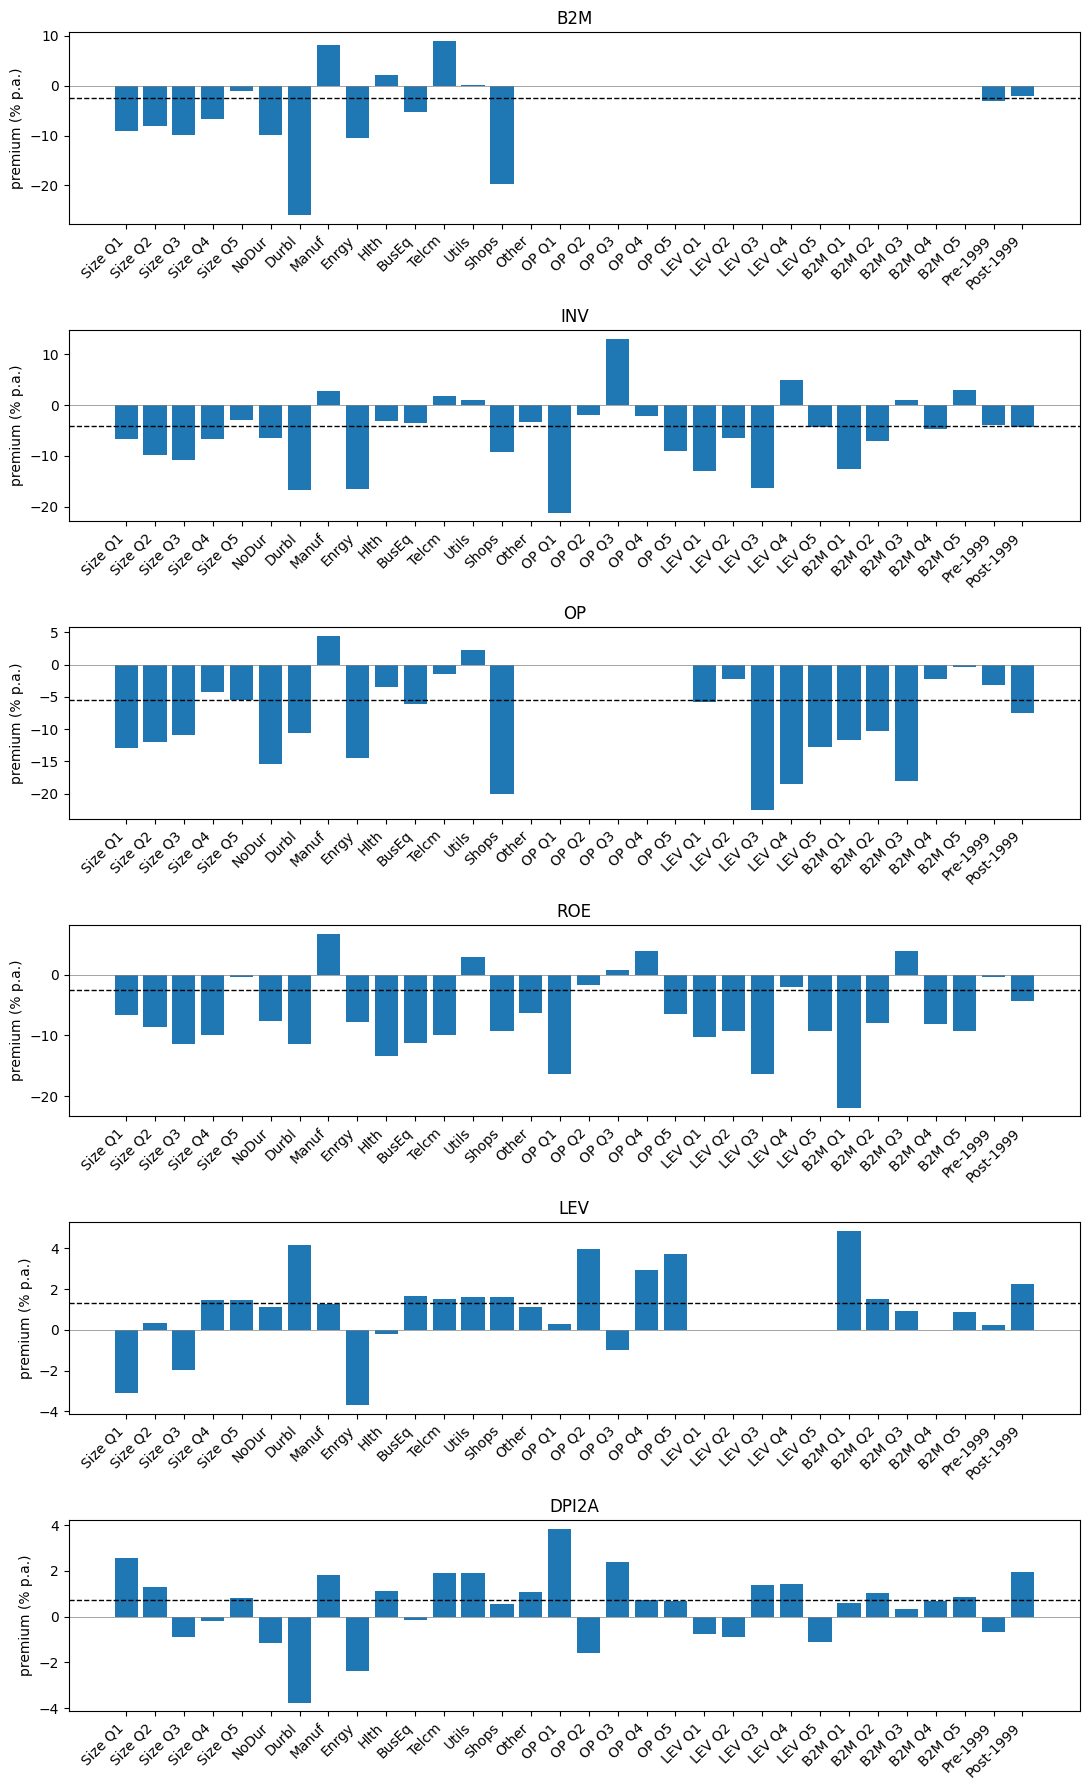

In [40]:
HIGHLIGHT_CHARS = ['B2M', 'INV', 'OP', 'ROE', 'LEV', 'DPI2A']

fig, axes = plt.subplots(len(HIGHLIGHT_CHARS), 1, figsize=(11, 3 * len(HIGHLIGHT_CHARS)))

x_size = [f'Size Q{q+1}' for q in range(5)]
x_ind = [f'{ind}' for ind in industries_present]
x_op = [f'OP Q{q+1}' for q in range(5)]
x_lev = [f'LEV Q{q+1}' for q in range(5)]
x_b2m = [f'B2M Q{q+1}' for q in range(5)]
x_sub = ['Pre-1999', 'Post-1999']

all_labels = x_size + x_ind + x_op + x_lev + x_b2m + x_sub

for ax, char_name in zip(axes, HIGHLIGHT_CHARS):
    if char_name not in PORT_TGT_CHARS:
        ax.set_visible(False)
        continue

    premiums = (
        [size_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [industry_results[ind].loc[char_name, 'premium'] for ind in industries_present] +
        [op_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [lev_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [b2m_results[q].loc[char_name, 'premium'] for q in range(5)] +
        [pre_result.loc[char_name, 'premium'], post_result.loc[char_name, 'premium']]
    )

    x_pos = np.arange(len(premiums))
    ax.bar(x_pos, premiums)
    ax.axhline(baseline.loc[char_name, 'premium'], color='k', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(all_labels, rotation=45, ha='right')
    ax.set_ylabel('premium (% p.a.)')
    ax.set_title(char_name)

plt.tight_layout()
plt.savefig('../images-pdfs/ablation_per_char_segments.pdf', bbox_inches='tight')
plt.show()